In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
# Load Sample Prognosis Dataset (Simulated ICU Data)
data = pd.DataFrame({
    'age': [70, 55, 80, 45, 67, 50, 76, 33, 60, 85],
    'blood_pressure': [120, 140, 110, 100, 90, 150, 130, 110, 125, 115],
    'heart_rate': [80, 95, 70, 85, 110, 100, 105, 72, 88, 76],
    'oxygen_level': [92, 88, 94, 96, 85, 90, 87, 98, 91, 93],
    'comorbidity_score': [2, 3, 4, 1, 5, 2, 3, 0, 2, 4],
    'outcome': [1, 1, 0, 0, 1, 0, 1, 0, 0, 1]  # 1 = Died, 0 = Survived
})

In [4]:
# Preprocessing
X = data.drop('outcome', axis=1)
y = data['outcome']

In [5]:
# Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [7]:
# Model Training (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("🔍 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.2f}")

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


📉 Confusion Matrix:
[[0 2]
 [0 1]]

🎯 ROC-AUC Score: 0.50


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


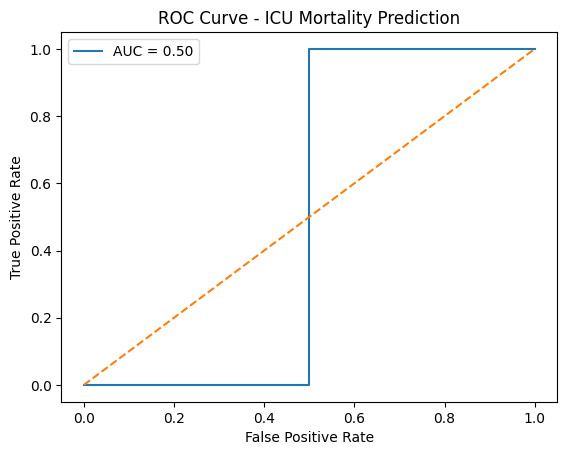

In [10]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ICU Mortality Prediction")
plt.legend()
plt.show()

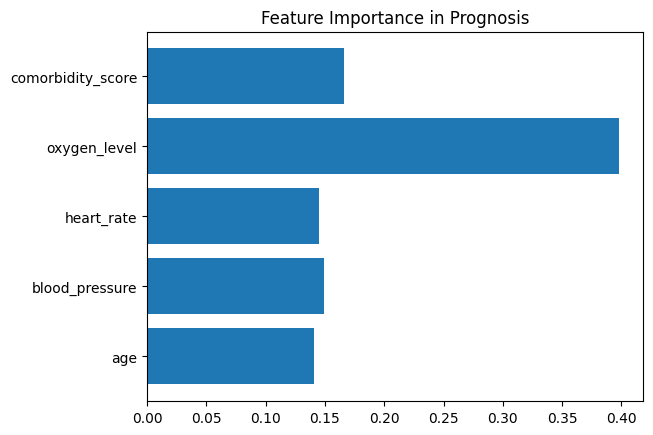

In [11]:
# Feature Importance
importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.title("Feature Importance in Prognosis")
plt.show()

### Conclusion

Here, we explored the differences between diagnosis (identifying disease) and prognosis (predicting outcomes), and implemented a machine learning pipeline to forecast patient outcomes. This lab emphasized the predictive role of AI in supporting long-term treatment decisions.

### Postlab

### **1. What is medical prognosis and how is AI used in this domain?**

**Medical prognosis** is the prediction of how a disease will progress — whether a patient will **recover**, **worsen**, or **die**.

**AI helps prognosis by:**

* Learning from **historical patient data**
* Forecasting **risks**, **disease progression**, and **treatment outcomes**
* Supporting **early interventions** and decision-making

---

### **2. Differentiate between diagnosis and prognosis in healthcare:**

| Category    | **Diagnosis**                   | **Prognosis**                       |
| ----------- | ------------------------------- | ----------------------------------- |
| **Goal**    | Identify current disease        | Predict future outcome              |
| **Example** | Does the patient have cancer?   | Will the cancer spread in 6 months? |
| **Input**   | Symptoms, test results, imaging | Diagnosis, vitals, history          |
| **Output**  | Disease label (e.g., pneumonia) | Survival probability, relapse risk  |

---

### **3. General Workflow of Implementing an AI Model for Medical Prognosis:**

1. **Define Prognosis Goal**
   (e.g., Predict survival time, risk of readmission)

2. **Collect Data**
   From EHRs, lab results, imaging, vitals, etc.

3. **Preprocess Data**
   Clean, handle missing values, encode categories, normalize

4. **EDA (Exploratory Data Analysis)**
   Visualize trends, plot survival curves, identify patterns

5. **Select and Train Model**
   Algorithms like **Random Forest**, **Logistic Regression**, **DeepSurv**, etc.

6. **Evaluate Model**
   Use metrics like **ROC-AUC**, **F1-score**, **C-index**

7. **Interpret Results**
   Use SHAP or LIME for feature importance and clinical transparency

8. **Deploy and Monitor**
   Integrate into hospital systems and track real-world performance

---

### **4. What is the role of feature engineering in medical prognosis tasks?**

**Feature engineering** plays a key role by:

* **Creating new variables** like BMI, comorbidity score, risk scores
* **Transforming raw data** (e.g., age groups, lab ranges) into usable input
* **Improving model performance** by highlighting important signals
* **Enhancing explainability** to provide clinicians with interpretable insights